Optimal Policy:
['R' 'R' 'R' 'D' 'D']
['U' 'X' 'R' 'R' 'D']
['D' 'U' 'X' 'R' 'D']
['D' 'X' 'R' 'D' 'D']
['R' 'R' 'R' 'R' 'G']


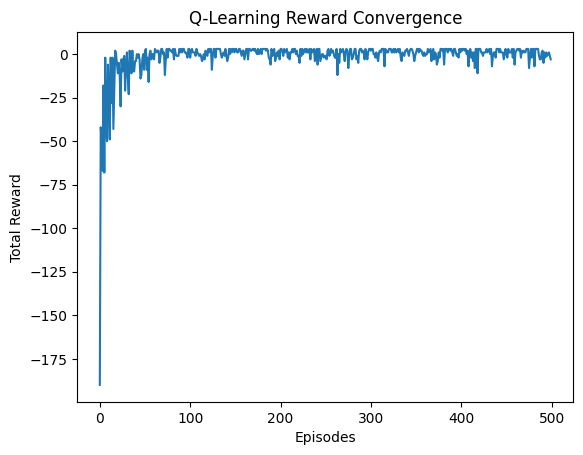

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# Environment Parameters
# -----------------------------
grid_size = 5
start_state = (0, 0)
goal_state = (4, 4)
obstacles = [(1, 1), (2, 2), (3, 1)]

# Actions: 0=up, 1=down, 2=left, 3=right
actions = ['U', 'D', 'L', 'R']

# -----------------------------
# Q-Learning Parameters
# -----------------------------
alpha = 0.1      # learning rate
gamma = 0.9      # discount factor
eps = 0.2        # exploration rate
episodes = 500

# Q-table
Q = np.zeros((grid_size, grid_size, 4))

# -----------------------------
# Step Function
# -----------------------------
def step(state, action):
    x, y = state

    if action == 0:      # up
        x -= 1
    elif action == 1:    # down
        x += 1
    elif action == 2:    # left
        y -= 1
    elif action == 3:    # right
        y += 1

    # Boundary condition
    if x < 0 or x >= grid_size or y < 0 or y >= grid_size:
        return state, -1, False

    new_state = (x, y)

    # Obstacle
    if new_state in obstacles:
        return state, -5, False

    # Goal reached
    if new_state == goal_state:
        return new_state, 10, True

    # Normal move
    return new_state, -1, False

# -----------------------------
# Training Loop
# -----------------------------
rewards_per_episode = []

for episode in range(episodes):
    state = start_state
    done = False
    total_reward = 0

    while not done:
        # ε-greedy action selection
        if np.random.rand() < eps:
            action = np.random.randint(4)
        else:
            action = np.argmax(Q[state])

        new_state, reward, done = step(state, action)

        # Q-learning update
        Q[state][action] += alpha * (
            reward + gamma * np.max(Q[new_state]) - Q[state][action]
        )

        state = new_state
        total_reward += reward

    rewards_per_episode.append(total_reward)

# -----------------------------
# Extract Optimal Policy
# -----------------------------
policy = np.full((grid_size, grid_size), ' ')

for i in range(grid_size):
    for j in range(grid_size):
        if (i, j) == goal_state:
            policy[i][j] = 'G'
        elif (i, j) in obstacles:
            policy[i][j] = 'X'
        else:
            policy[i][j] = actions[np.argmax(Q[i, j])]

# -----------------------------
# Display Policy
# -----------------------------
print("Optimal Policy:")
for row in policy:
    print(row)

# -----------------------------
# Plot Reward Convergence
# -----------------------------
plt.plot(rewards_per_episode)
plt.xlabel("Episodes")
plt.ylabel("Total Reward")
plt.title("Q-Learning Reward Convergence")
plt.show()